Yeom's request: 
1) phase map을 그리자
2) 통계 추정치를 뽑아내자.

# Load Data

In [36]:
from useful import auto199

In [38]:
import imagingPhase.load_data as ld
fn = './phaseAnalysis3/2HTaSe_cea_100K037_crop.gwy'
import gwyfile
import numpy as np
container = gwyfile.load(fn)
arr = container['/15/data']['data']
arr = arr.reshape([322,1024])
print('I can read the variables in outside')


I can read the variables in outside


In [33]:
arr.shape[0]/1024

1.0

# Quick preprocess

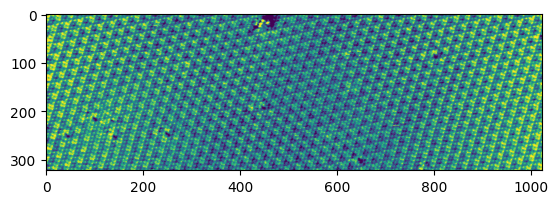

In [39]:
from matplotlib import pyplot as plt
# plt.imshow(arr[0:1000,0:1000])
plt.imshow(arr)
auto199()

In [40]:
from scipy.ndimage import gaussian_filter
def ceilcut(arr2,threshold=1*10**-10):
  arr2[arr2>threshold] = threshold
  return arr2
def highpass(arr2,sigma=5):
  
  arr2 = arr2 - gaussian_filter(arr2,sigma=sigma)
  return arr2



In [41]:
print(arr.flatten().max())
print(arr.flatten().min())

-1.452846344073277e-07
-1.4539968300437665e-07


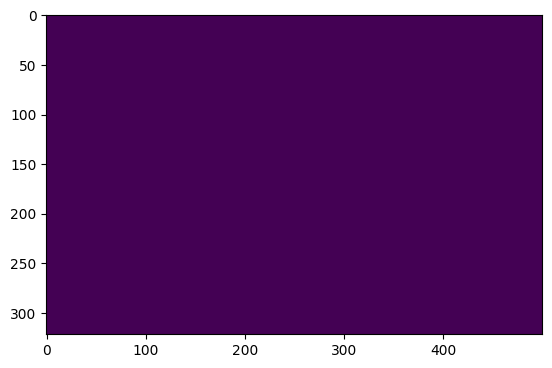

In [42]:
# plt.hist(arr.flatten().max)
plt.imshow(arr[0:500,0:500]>1*10**-10)

d:\github\2H_TaSe2_Tc_STM\2Hvenv\Lib\site-packages\numpy\lib\_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


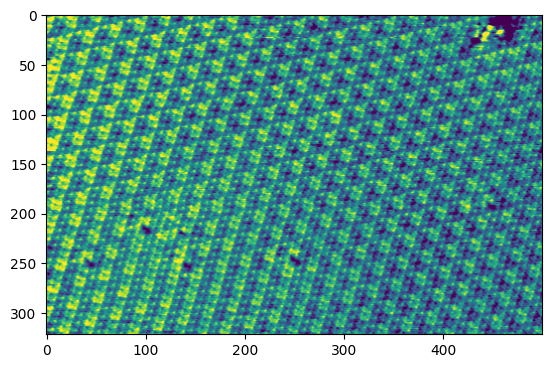

In [43]:
plt.imshow(arr[0:500,0:500])
auto199()

In [44]:
arr_after = highpass(ceilcut(arr)) 

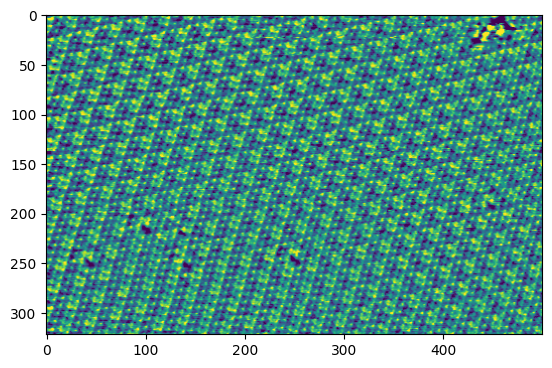

In [45]:
plt.imshow(arr_after[0:500,0:500])
auto199()

In [46]:
# from scipy.fft import fft2, fftshift
# from skimage.feature import peak_local_max
# def fft2show(arr_cln,vmin,vmax):
#   fft_result = fft2(arr_cln)
#   fft_result_shifted = fftshift(fft_result)
#   magnitude_spectrum = np.abs(fft_result_shifted)
#   plt.figure(figsize=(10, 10))
#   plt.imshow(magnitude_spectrum, cmap='gray', vmin=vmin, vmax=vmax)
#   plt.title('Magnitude Spectrum of 2D FFT')
#   return  magnitude_spectrum
# def fft2pkfnd(fft2abs,threshold,choose):
#   coordinates = peak_local_max(fft2abs, min_distance=100, threshold_abs = threshold)
#   plt.scatter(coordinates[:, 1], coordinates[:, 0], s=50, facecolors='none', edgecolors='r')
#   for ipeak in range(coordinates.shape[0]):
#     plt.text(coordinates[ipeak,1],coordinates[ipeak,0],str(ipeak), color='g')
#   coordinates_choose = coordinates[choose,:]
#   print(coordinates_choose)
#   print(coordinates_choose.shape[0])
#   for ipeak in range(coordinates_choose.shape[0]):
#     plt.text(coordinates_choose[ipeak,1],coordinates_choose[ipeak,0],str(ipeak), color='b',size= 20)
#     pk_all = coordinates - (np.array(fft2abs.shape)/2)
#     pk_choose = pk_all[choose,:]
#   return pk_choose,pk_all
arr_cln = arr_after

In [80]:
vmin = 0 # @param
vmax = 0.0000001 # @param
threshold = 0.00000002 # @param
choose = [6,10,12] # @param

In [66]:
from imagingPhase.ffts import fft2show,fft2pkfnd

In [67]:
fft2show

<function imagingPhase.ffts.fft2show(arr_cln, vmin=None, vmax=None)>

[[148 375]
 [113 475]
 [127 612]]
3
[[ -13. -137.]
 [ -48.  -37.]
 [ -34.  100.]]
[[ -43.    8.]
 [  43.   -8.]
 [ -11.   33.]
 [  11.  -33.]
 [  -4.  -45.]
 [   4.   45.]
 [ -13. -137.]
 [  13.  137.]
 [ -16.  -12.]
 [  16.   12.]
 [ -48.  -37.]
 [  48.   37.]
 [ -34.  100.]
 [  34. -100.]
 [ -32.  -24.]
 [  32.   24.]
 [  -9.  -92.]
 [   9.   92.]
 [ -39.   55.]
 [  39.  -55.]
 [ -62. -174.]
 [  62.  174.]
 [ -69.  200.]
 [  69. -200.]
 [ -36.  -70.]
 [  36.   70.]
 [ -82.   63.]
 [  82.  -63.]
 [ -59.   -4.]
 [  59.    4.]
 [ -25. -104.]
 [  25.  104.]
 [ -50.   88.]
 [  50.  -88.]
 [ -28. -275.]
 [  28.  275.]
 [ -21.  238.]
 [  21. -238.]
 [ -27.   22.]
 [  27.  -22.]
 [ -80.  -60.]
 [  80.   60.]
 [ -87.   18.]
 [  87.  -18.]]


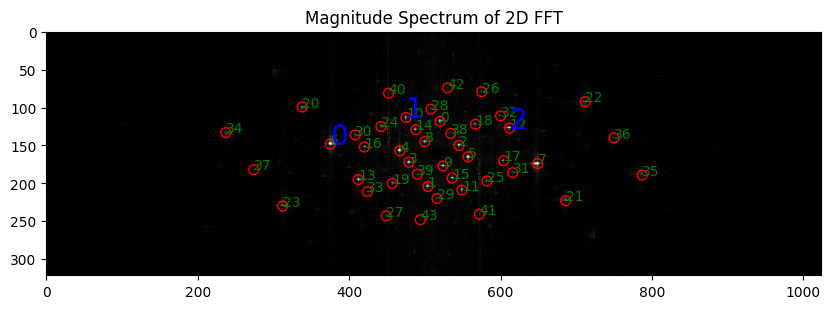

In [81]:
# from imagingPhase import fft2show
fft2abs = fft2show(arr_cln,vmin,vmax)
pk_choose,pk_all = fft2pkfnd(fft2abs,threshold,choose,min_distance=10)
print(pk_choose)
print(pk_all)

Text(0.5, 0.98, 'k0')

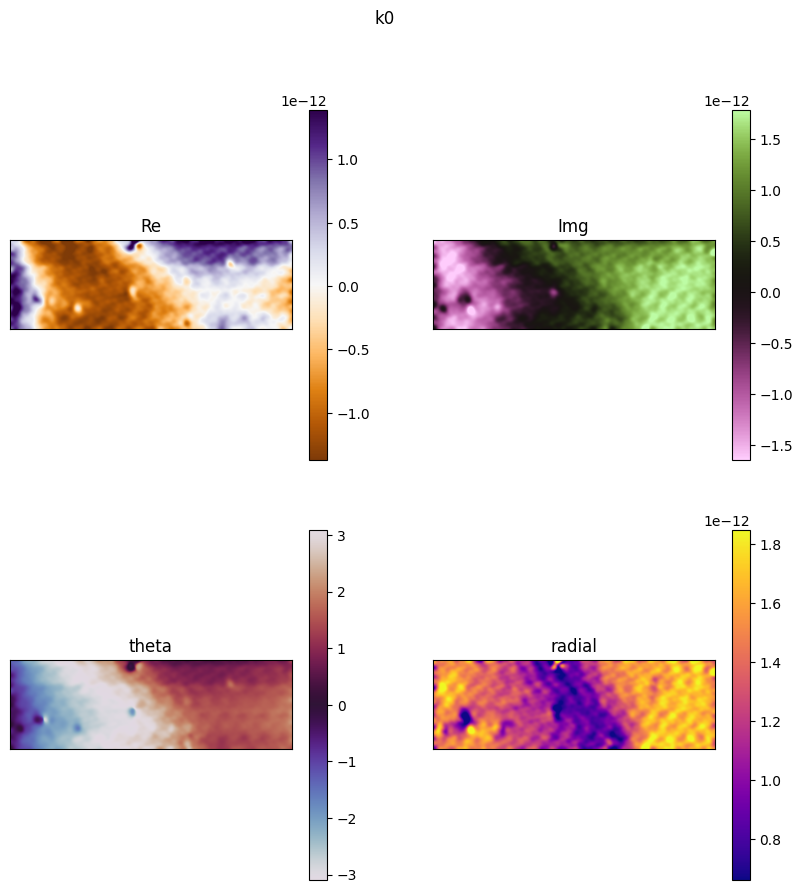

In [82]:
from imagingPhase.get_phimap import kdisplacementmap, visxprod

ik = 0 # @param
k = pk_choose[ik]/3
sig = 10 # @para
xprod = kdisplacementmap(arr_cln,k,sig)
visxprod(xprod)
plt.suptitle("k"+str(ik))


In [83]:
ks_Latt = pk_choose
ks_CDW = pk_choose/3

In [84]:
def wrap_phase(unwrapped_phase):
  """
  Wraps unwrapped phase data into the range of (-pi, pi].

  Args:
    unwrapped_phase: A numpy array containing the unwrapped phase data.

  Returns:
    A numpy array containing the wrapped phase data.
  """
  wrapped_phase = np.mod(unwrapped_phase + np.pi, 2 * np.pi) - np.pi
  return wrapped_phase
from skimage.restoration import unwrap_phase

In [85]:

sig = 20 # @param
angle_restores = []
complexs = []
for ik in range(3):
  k_Latt = ks_Latt[ik]
  k_CDW = ks_CDW[ik]
  complex = kdisplacementmap(arr_cln,k_CDW,sig)
  angle_restore = (unwrap_phase(np.angle(complex))- unwrap_phase(np.angle(kdisplacementmap(arr_cln,k_Latt,sig)))/3)
  angle_restores.append(angle_restore)
  complexs.append(complex)




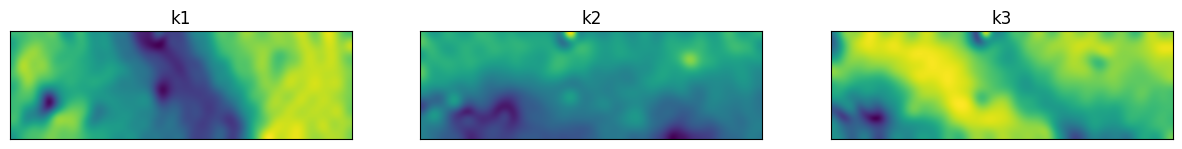

In [86]:
fig,axs = plt.subplots(1,3,figsize=(15, 15))
tns = ['k1','k2','k3']
for ik,tn in zip(range(3),tns):
    # reimg = angle_restores[ik]
    # reimg = wrap_phase(reimg)
    reimg = np.abs(complexs[ik])
    axs[ik].imshow(reimg)
    axs[ik].set_title(tn)
    axs[ik].set_xticks([])
    axs[ik].set_yticks([])

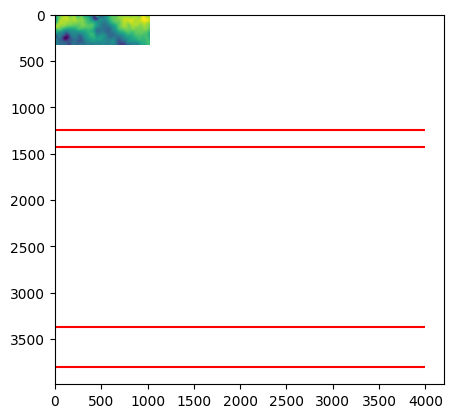

In [87]:
y_surgerys = [1250,1425,3375,3800]
reimg = np.abs(complexs[0])+np.abs(complexs[1])+np.abs(complexs[2])
plt.imshow(reimg)
plt.hlines(y_surgerys,xmin=0,xmax=4000,color='r')

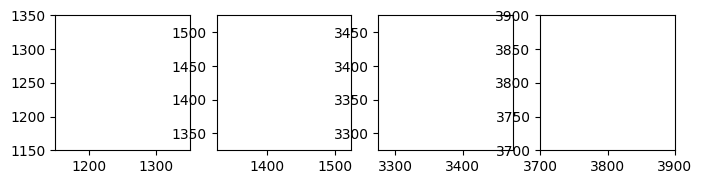

In [88]:
from IPython.core.pylabtools import figsize
l_half = 100
msb,nsb = 1,4
fig,axs = plt.subplots(1,4,figsize=(8,2))
for jsb,ax,y_surgery in zip(range(4),axs,y_surgerys):     
    ax.imshow(arr_cln)
    plt.sca(ax)
    auto199()
    ax.set_xlim([y_surgery-l_half,y_surgery+l_half])
    ax.set_ylim([y_surgery-l_half,y_surgery+l_half])
    
    
        

In [92]:
reimg.shape

(322, 1024)

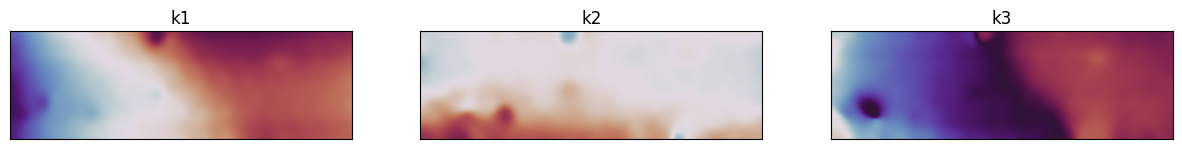

In [89]:
fig,axs = plt.subplots(1,3,figsize=(15, 15))
tns = ['k1','k2','k3']
for ik,tn in zip(range(3),tns):
    # reimg = angle_restores[ik]
    # reimg = wrap_phase(reimg)
    reimg = np.angle(complexs[ik])
    axs[ik].imshow(reimg,cmap='twilight')
    axs[ik].set_title(tn)
    axs[ik].set_xticks([])
    axs[ik].set_yticks([])

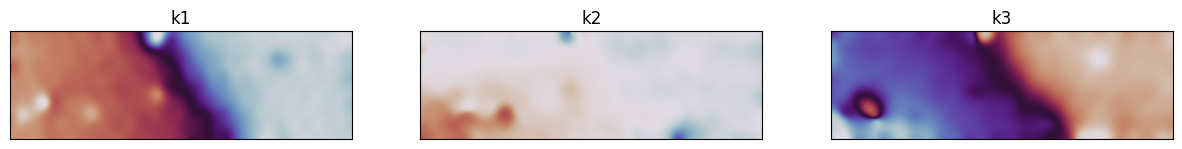

In [113]:
fig,axs = plt.subplots(1,3,figsize=(15, 15))
tns = ['k1','k2','k3']
yns = ['CDW','atom','CDW_compensate']
phis = np.array([-1,0,0])*np.pi*(2/3)
for ik,tn,phi in zip(range(3),tns,phis):
    reimg = angle_restores[ik] +phi
    reimg = wrap_phase(reimg) 
    axs[ik].imshow(reimg, cmap='twilight')
    axs[ik].set_title(tn)
    axs[ik].set_xticks([])
    axs[ik].set_yticks([])

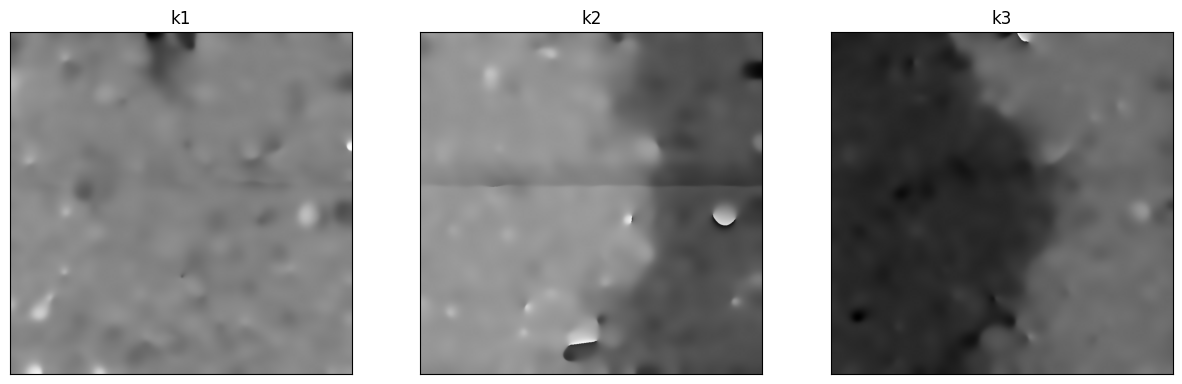

In [51]:
fig,axs = plt.subplots(1,3,figsize=(15, 15))
tns = ['k1','k2','k3']
yns = ['CDW','atom','CDW_compensate']
for ik,tn in zip(range(3),tns):
    reimg = angle_restores[ik]
    # reimg = wrap_phase(reimg)
    axs[ik].imshow(reimg,cmap='gray')
    axs[ik].set_title(tn)
    axs[ik].set_xticks([])
    axs[ik].set_yticks([])

In [26]:
lin = np.arange(4096)
y_surgerys
step1 = (lin>y_surgerys[1])*np.pi*(2/3)- np.pi*(2/3)
step2 = (lin>y_surgerys[0])*np.pi*(2/3)*3 +(lin>y_surgerys[1])*np.pi*(2/3)*2+(lin>y_surgerys[2])*np.pi*(2/3)*2
step3 = (lin>y_surgerys[0])*np.pi*(2/3)*3 +(lin>y_surgerys[2])*np.pi*(2/3)
steps = [step1,step2,step3]

# print(foo)

ValueError: operands could not be broadcast together with shapes (1024,1024) (4096,1) 

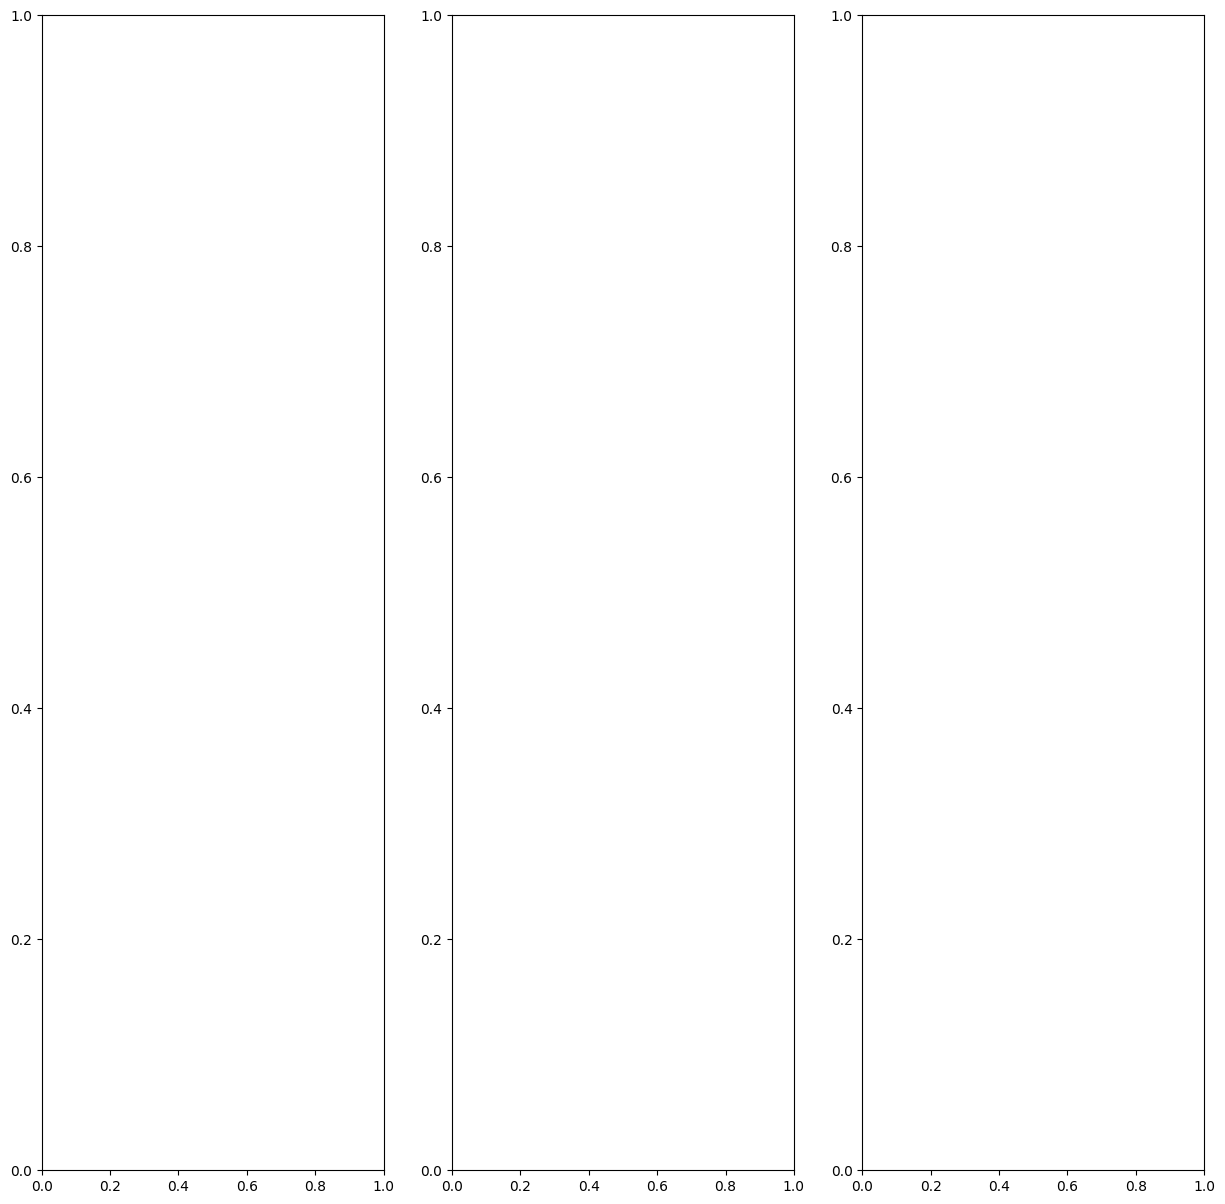

In [27]:
fig,axs = plt.subplots(1,3,figsize=(15, 15))
tns = ['k1','k2','k3']
yns = ['CDW','atom','CDW_compensate']
phase = []
for ik,tn,step in zip(range(3),tns,steps):
    reimg = angle_restores[ik]+step.reshape(4096,1)
    phase.append(reimg)
    reimg = wrap_phase(reimg)
    axs[ik].imshow(reimg, cmap='twilight')
    axs[ik].set_title(tn)
    axs[ik].set_xticks([])
    axs[ik].set_yticks([])

(array([218944., 219589., 220098., 220575., 216575., 215048., 214542.,
        211227., 206640., 204209., 198973., 197580., 193400., 186171.,
        180463., 175527., 166040., 156563., 148572., 142610., 137349.,
        131077., 125614., 121278., 114879., 108210., 102332.,  98504.,
         94538.,  90669.,  87280.,  84385.,  82061.,  78212.,  76984.,
         73320.,  70877.,  69018.,  66805.,  63622.,  61302.,  59236.,
         56837.,  54928.,  53452.,  51300.,  49586.,  47735.,  45881.,
         44119.,  42987.,  41730.,  40299.,  38830.,  37568.,  36380.,
         35417.,  34295.,  33157.,  31851.,  31076.,  29833.,  28722.,
         27415.,  26427.,  25861.,  25310.,  24091.,  23097.,  22446.,
         21984.,  21709.,  20921.,  20197.,  19569.,  18817.,  18522.,
         17813.,  17338.,  16937.,  16563.,  15949.,  15536.,  15100.,
         14548.,  14185.,  13871.,  13561.,  13046.,  12551.,  12380.,
         11718.,  11430.,  11154.,  11054.,  10520.,  10248.,  10164.,
      

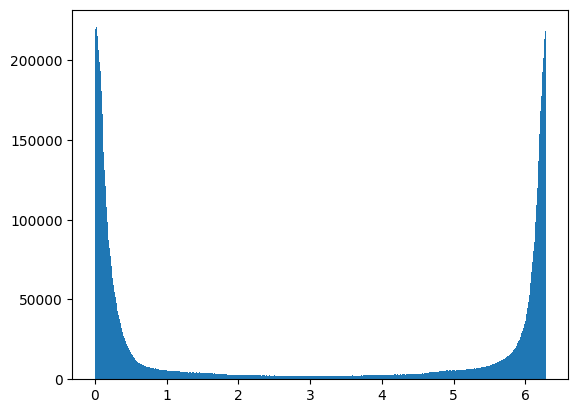

In [ ]:
g0,g1 = -.92,-.98
gs = [g0,g1]
phase_fixed = [phase[0]+g0,phase[1]+g1]
ik = 1
plt.hist(np.mod(3*(phase_fixed[ik].flatten()),np.pi*2),bins=1000)

In [ ]:
from imagingPhase.visPhase import phiPrinter
pp = phiPrinter([phase_fixed[0],phase_fixed[1]])

phase uploaded
phase calculated


(array([ 26580.,  26135.,  25121.,  24319.,  23947.,  22970.,  22178.,
         22035.,  21165.,  20906.,  20072.,  19249.,  18700.,  18166.,
         17899.,  17228.,  17077.,  16623.,  15965.,  16033.,  15620.,
         15280.,  14728.,  14794.,  14287.,  13890.,  13658.,  13578.,
         13166.,  12975.,  12713.,  12442.,  12373.,  12139.,  12076.,
         11554.,  11562.,  11424.,  11361.,  11242.,  11227.,  10987.,
         10618.,  10680.,  10374.,  10090.,  10113.,   9963.,   9837.,
          9950.,   9587.,   9510.,   9349.,   9328.,   9076.,   8951.,
          8705.,   8497.,   8361.,   8272.,   8237.,   8118.,   8177.,
          7946.,   7728.,   7878.,   7708.,   7636.,   7563.,   7476.,
          7541.,   7400.,   7393.,   7130.,   6997.,   6937.,   6814.,
          6673.,   6681.,   6808.,   6655.,   6526.,   6484.,   6556.,
          6464.,   6521.,   6370.,   6255.,   6242.,   6149.,   6059.,
          6127.,   6045.,   5885.,   5839.,   5776.,   5847.,   5520.,
      

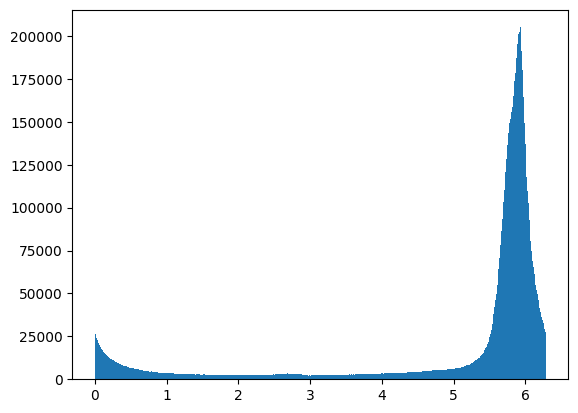

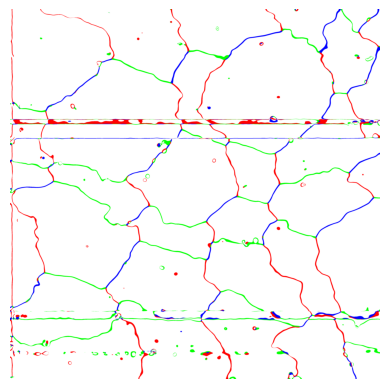

In [ ]:
from imagingPhase.visPhase import DWallColoring
dwc = DWallColoring(pp.Info,pp.phase)
dwc.show()